In [1]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from compression import VanillaQuantization, VanillaSparsification
from compression import FpQuantization, QuantileQuantization
from compression import RandTopkSparsification, MaskSparsification

from torch.distributions import Exponential, Gamma

In [2]:
def seed_it(seed):
    random.seed(seed)
    os.environ["PYTHONSEED"] = str(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True
    torch.manual_seed(seed)

In [3]:
seed_it(42)

$q_1d=q_2d+fk_2$

$d+fk_1=q_2d+fk_2$

In [4]:
def compressor(d, q2, f=32):
    q1 = q2 + 1
    k1 = q2 * d // f
    k2 = d // f
    vq = VanillaQuantization(bit=q1)
    qq = QuantileQuantization(bit=q1, offset=0.99, asymmetric=False)
    fq = FpQuantization(exponent_bits=q1 // 2, mantissa_bits=q1 - (q1 // 2))

    vs = VanillaSparsification(k=k1, ratio=None)
    rt = RandTopkSparsification(k=k1, alpha=0.1, ratio=None)
    ms = MaskSparsification(k=k2, bit=q2, ratio=None, positive=True)

    compressor = {
        'vq': vq,
        'qq': qq,
        'fpq': fq,
        'vs': vs,
        'rts': rt,
        'ms': ms,
    }
    return compressor

In [5]:
def test(compressor, x):
    with torch.no_grad():
        x = torch.relu(x)
        res = {}
        for n, c in compressor.items():
            t = time.time()
            y = c.decode(*c.encode(x))
            t = round((time.time() - t), 4)
            norm = torch.norm(x - y)
            res[n] = norm
    return res

In [6]:
d = int(1e6)
attemp = 10
result = {'vq': [], 'qq': [], 'fpq': [], 'vs': [], 'rts': [], 'ms': []}

for i in range(2, 9):
    comps = compressor(d, i)
    for _ in range(attemp):
        x = torch.normal(mean=0, std=1, size=(d, ))
        tmp = test(comps, x)
        for i, k in tmp.items():
            result[i].append(k.item())

res_normal = {
    'MS': [(np.mean(result['ms'][i*10:i*10+10]).item(), np.var(result['ms'][i*10:i*10+10]).item()) for i in range(7)],
    'VQ': [(np.mean(result['vq'][i*10:i*10+10]).item(), np.var(result['vq'][i*10:i*10+10]).item()) for i in range(7)],
    'QQ': [(np.mean(result['qq'][i*10:i*10+10]).item(), np.var(result['qq'][i*10:i*10+10]).item()) for i in range(7)],
    'VS': [(np.mean(result['vs'][i*10:i*10+10]).item(), np.var(result['vs'][i*10:i*10+10]).item()) for i in range(7)],
    'FPQ': [(np.mean(result['fpq'][i*10:i*10+10]).item(), np.var(result['fpq'][i*10:i*10+10]).item()) for i in range(7)],
    'RTS': [(np.mean(result['rts'][i*10:i*10+10]).item(), np.var(result['rts'][i*10:i*10+10]).item()) for i in range(7)],
}

In [7]:
d = int(1e6)
attemp = 10
result = {'vq': [], 'qq': [], 'fpq': [], 'vs': [], 'rts': [], 'ms': []}

for i in range(2, 9):
    comps = compressor(d, i)
    for _ in range(attemp):
        x = torch.rand((d, )) * 2 - 1
        tmp = test(comps, x)
        for i, k in tmp.items():
            result[i].append(k.item())

res_uniform = {
    'MS': [(np.mean(result['ms'][i*10:i*10+10]).item(), np.var(result['ms'][i*10:i*10+10]).item()) for i in range(7)],
    'VQ': [(np.mean(result['vq'][i*10:i*10+10]).item(), np.var(result['vq'][i*10:i*10+10]).item()) for i in range(7)],
    'QQ': [(np.mean(result['qq'][i*10:i*10+10]).item(), np.var(result['qq'][i*10:i*10+10]).item()) for i in range(7)],
    'VS': [(np.mean(result['vs'][i*10:i*10+10]).item(), np.var(result['vs'][i*10:i*10+10]).item()) for i in range(7)],
    'FPQ': [(np.mean(result['fpq'][i*10:i*10+10]).item(), np.var(result['fpq'][i*10:i*10+10]).item()) for i in range(7)],
    'RTS': [(np.mean(result['rts'][i*10:i*10+10]).item(), np.var(result['rts'][i*10:i*10+10]).item()) for i in range(7)],
}

In [8]:
d = int(1e6)
attemp = 10
result = {'vq': [], 'qq': [], 'fpq': [], 'vs': [], 'rts': [], 'ms': []}

dist_exp = Exponential(rate=1)

for i in range(2, 9):
    comps = compressor(d, i)
    for _ in range(attemp):
        x = dist_exp.sample((d, ))
        tmp = test(comps, x)
        for i, k in tmp.items():
            result[i].append(k.item())

res_exp = {
    'MS': [(np.mean(result['ms'][i*10:i*10+10]).item(), np.var(result['ms'][i*10:i*10+10]).item()) for i in range(7)],
    'VQ': [(np.mean(result['vq'][i*10:i*10+10]).item(), np.var(result['vq'][i*10:i*10+10]).item()) for i in range(7)],
    'QQ': [(np.mean(result['qq'][i*10:i*10+10]).item(), np.var(result['qq'][i*10:i*10+10]).item()) for i in range(7)],
    'VS': [(np.mean(result['vs'][i*10:i*10+10]).item(), np.var(result['vs'][i*10:i*10+10]).item()) for i in range(7)],
    'FPQ': [(np.mean(result['fpq'][i*10:i*10+10]).item(), np.var(result['fpq'][i*10:i*10+10]).item()) for i in range(7)],
    'RTS': [(np.mean(result['rts'][i*10:i*10+10]).item(), np.var(result['rts'][i*10:i*10+10]).item()) for i in range(7)],
}

In [9]:
d = int(1e6)
attemp = 10
result = {'vq': [], 'qq': [], 'fpq': [], 'vs': [], 'rts': [], 'ms': []}

dist_gamma = Gamma(concentration=2.0, rate=1.0)


for i in range(2, 9):
    comps = compressor(d, i)
    for _ in range(attemp):
        x = dist_gamma.sample((d, ))
        tmp = test(comps, x)
        for i, k in tmp.items():
            result[i].append(k.item())

res_gamma = {
    'MS': [(np.mean(result['ms'][i*10:i*10+10]).item(), np.var(result['ms'][i*10:i*10+10]).item()) for i in range(7)],
    'VQ': [(np.mean(result['vq'][i*10:i*10+10]).item(), np.var(result['vq'][i*10:i*10+10]).item()) for i in range(7)],
    'QQ': [(np.mean(result['qq'][i*10:i*10+10]).item(), np.var(result['qq'][i*10:i*10+10]).item()) for i in range(7)],
    'VS': [(np.mean(result['vs'][i*10:i*10+10]).item(), np.var(result['vs'][i*10:i*10+10]).item()) for i in range(7)],
    'FPQ': [(np.mean(result['fpq'][i*10:i*10+10]).item(), np.var(result['fpq'][i*10:i*10+10]).item()) for i in range(7)],
    'RTS': [(np.mean(result['rts'][i*10:i*10+10]).item(), np.var(result['rts'][i*10:i*10+10]).item()) for i in range(7)],
}

In [10]:
fontsize = 22
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.titlesize'] = fontsize

In [11]:
colors = [
    '#1f77b4',  # 蓝色 (Tableau Blue)
    '#ff7f0e',  # 橙色 (Tableau Orange)
    '#2ca02c',  # 绿色 (Tableau Green)
    '#d62728',  # 红色 (Tableau Red)
    '#9467bd',  # 紫色 (Tableau Purple)
    '#8c564b'   # 棕色 (Tableau Brown)
]

line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 5))]

markers = ['D', 's', 'o', '^', 'v', '.']

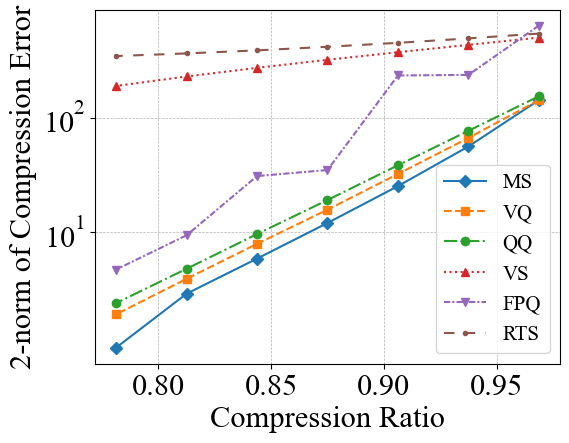

In [19]:
x = list(map(lambda x : 1 - x / 32, list(range(1, 8))))

plt.figure(figsize=(6, 4.6))
plt.yscale('symlog')
plt.xlabel('Compression Ratio')
plt.ylabel('2-norm of Compression Error')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for idx, (i, j) in enumerate(res_normal.items()):
    mean = [k[0] for k in j]
    plt.plot(x, mean, label=i, color=colors[idx], linestyle=line_styles[idx], marker=markers[idx])
plt.legend()
plt.savefig('img/error_normal_positive.pdf', dpi=600, format='pdf', pad_inches=0.06, bbox_inches='tight')

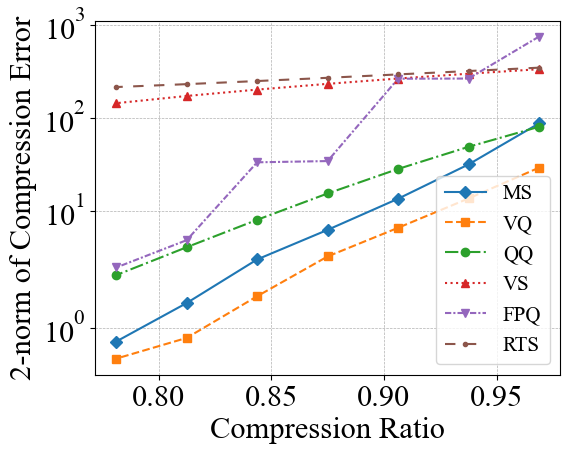

In [20]:
x = list(map(lambda x : 1 - x / 32, list(range(1, 8))))

plt.figure(figsize=(6, 4.6))
plt.yscale('symlog')
plt.xlabel('Compression Ratio')
plt.ylabel('2-norm of Compression Error')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for idx, (i, j) in enumerate(res_uniform.items()):
    mean = [k[0] for k in j]
    plt.plot(x, mean, label=i, color=colors[idx], linestyle=line_styles[idx], marker=markers[idx])
plt.legend()
plt.savefig('img/error_uniform_positive.pdf', dpi=600, format='pdf', pad_inches=0.06, bbox_inches='tight')

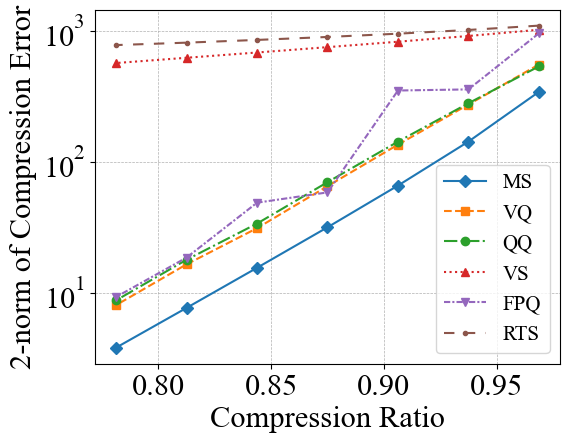

In [21]:
x = list(map(lambda x : 1 - x / 32, list(range(1, 8))))

plt.figure(figsize=(6, 4.6))
plt.yscale('symlog')
plt.xlabel('Compression Ratio')
plt.ylabel('2-norm of Compression Error')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for idx, (i, j) in enumerate(res_exp.items()):
    mean = [k[0] for k in j]
    plt.plot(x, mean, label=i, color=colors[idx], linestyle=line_styles[idx], marker=markers[idx])
plt.legend()
plt.savefig('img/error_exp_positive.pdf', dpi=600, format='pdf', pad_inches=0.06, bbox_inches='tight')

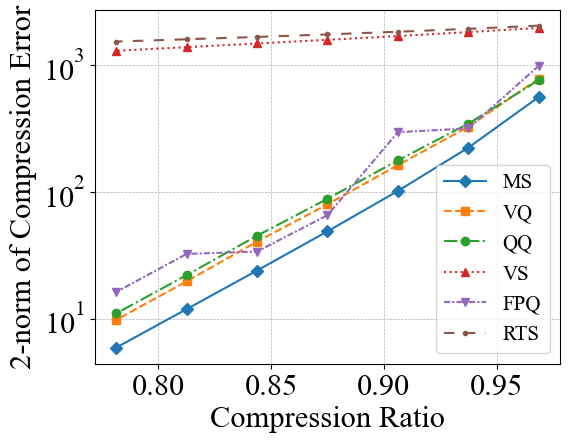

In [22]:
x = list(map(lambda x : 1 - x / 32, list(range(1, 8))))

plt.figure(figsize=(6, 4.6))
plt.yscale('symlog')
plt.xlabel('Compression Ratio')
plt.ylabel('2-norm of Compression Error')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for idx, (i, j) in enumerate(res_gamma.items()):
    mean = [k[0] for k in j]
    plt.plot(x, mean, label=i, color=colors[idx], linestyle=line_styles[idx], marker=markers[idx])
plt.legend()
plt.savefig('img/error_gamma_positive.pdf', dpi=600, format='pdf', pad_inches=0.06, bbox_inches='tight')